# CIFAR-10 Transfer Learning with ResNet-34

Fine-tuning a pre-trained ResNet-34 (ImageNet weights) on CIFAR-10.

**Strategy:**
- Resize CIFAR-10 images from 32x32 → 224x224 (ImageNet standard)
- Load `resnet34(weights='DEFAULT')` with pre-trained weights
- Replace the final FC layer for 10 classes
- Fine-tune with SGD + OneCycleLR (lower max_lr since weights are already good)
- Use `ModelCheckpoint` from `utils/callbacks` for crash protection & best model saving

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import matplotlib.pyplot as plt
import numpy as np
import time

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## Data Pipeline

Since the pre-trained ResNet-34 was trained on 224x224 ImageNet images,
we resize CIFAR-10 images to 224x224 to match the expected input resolution.
We use ImageNet normalization stats since the backbone was pre-trained with them.

In [3]:
# ImageNet normalization (matches the pre-trained weights)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(224),  # Upscale to ImageNet resolution
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=28),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.5),
])

val_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Batch size: 64 is safer for 224x224 on a single GPU
batch_size = 64

full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True
)

train_idx, val_idx = torch.utils.data.random_split(
    range(len(full_trainset)), [0.8, 0.2]
)

trainset = torch.utils.data.Subset(
    torchvision.datasets.CIFAR10(root='./data', train=True, transform=train_tf),
    train_idx.indices
)

valset = torch.utils.data.Subset(
    torchvision.datasets.CIFAR10(root='./data', train=True, transform=val_tf),
    val_idx.indices
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True
)
valloader = torch.utils.data.DataLoader(
    valset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=val_tf
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f'Train: {len(trainset)} | Val: {len(valset)} | Test: {len(testset)}')

C:\Users\asmit\PycharmProjects\TorchT\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 40000 | Val: 10000 | Test: 10000


## Model: Pre-trained ResNet-34

We load the ResNet-34 backbone with ImageNet weights,
then replace the final fully connected layer to output 10 classes.

The `BasicBlock` structure is identical to our custom ResNet-18,
but ResNet-34 is deeper (34 layers vs 18), giving it more capacity
to learn complex features — all while keeping the same lightweight block design.

In [4]:
# Load pre-trained ResNet-34
classifier = models.resnet34(weights='DEFAULT')

# Replace the final FC layer (originally 1000 classes → 10 for CIFAR-10)
num_features = classifier.fc.in_features  # 512
classifier.fc = nn.Linear(num_features, 10)

classifier.to(device)
print(f'Model parameters: {sum(p.numel() for p in classifier.parameters()):,}')

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\asmit/.cache\torch\hub\checkpoints\resnet34-b627a593.pth


100.0%


Model parameters: 21,289,802


## Callbacks: ModelCheckpoint

In [5]:
from utils.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    model=classifier,
    checkpoint_path='./checkpoint/resnet34_transfer_latest.pth',
    best_model_path='./checkpoint/resnet34_transfer_best.pth',
    mode='max',  # Track validation accuracy (higher is better)
    verbose=True,
)

## Training Configuration

Since the backbone is already pre-trained, we use a **lower max learning rate** (`0.01`)
compared to training from scratch (`0.1`). This prevents the fine-tuning from
destroying the pre-trained features.

With transfer learning, **30 epochs** is more than enough to converge.

In [6]:
criterion = nn.CrossEntropyLoss()
epochs = 30
optimizer = optim.SGD(classifier.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01,  # Lower max_lr for fine-tuning pre-trained weights
    steps_per_epoch=len(trainloader),
    epochs=epochs,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=1e3
)

# Optimization: AMP Scaler
scaler = torch.amp.GradScaler('cuda')

## Training Loop

In [7]:
train_losses, val_losses, val_accuracies = [], [], []
epoc_start = time.time()

for epoch in range(epochs):
    classifier.train()
    epoch_loss = 0.0
    n_batches = 0
    start_time = time.time()

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # Optimization: Mixed Precision Forward Pass
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = classifier(inputs)
            loss = criterion(outputs, labels)

        # Optimization: Scaled Backward Pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # OneCycleLR MUST step after every mini-batch
        scheduler.step()

        epoch_loss += loss.item()
        n_batches += 1

    # ─── Per-epoch logging ────────────────────────────────────
    avg_train_loss = epoch_loss / n_batches
    train_losses.append(avg_train_loss)

    # Validation: loss + accuracy in one pass
    classifier.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, lbls in valloader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                out = classifier(imgs)
            val_loss += criterion(out, lbls).item()
            _, predicted = torch.max(out, 1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()

    avg_val_loss = val_loss / len(valloader)
    val_acc = 100.0 * correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    # Save checkpoint & best model
    checkpoint(val_acc, epoch, optimizer, scheduler, scaler)

    current_lr = scheduler.get_last_lr()[0]
    print(
        f'Epoch [{epoch+1:2d}/{epochs}]  '
        f'Train Loss: {avg_train_loss:.4f}  '
        f'Val Loss: {avg_val_loss:.4f}  '
        f'Val Acc: {val_acc:.2f}%  '
        f'LR: {current_lr:.6f} '
        f'Time: {time.time() - start_time:.2f}s'
    )

print(f'\nFinished Training in {(time.time() - epoc_start)/60:.2f} minutes')
print(f'Best Validation Accuracy: {checkpoint.best_score:.2f}%')

[ModelCheckpoint] New best (max): 93.4900 — saved to checkpoint\resnet34_transfer_best.pth
Epoch [ 1/30]  Train Loss: 0.7358  Val Loss: 0.1893  Val Acc: 93.49%  LR: 0.001271 Time: 46.66s
[ModelCheckpoint] New best (max): 94.0500 — saved to checkpoint\resnet34_transfer_best.pth
Epoch [ 2/30]  Train Loss: 0.4223  Val Loss: 0.1731  Val Acc: 94.05%  LR: 0.002053 Time: 27.05s
[ModelCheckpoint] New best (max): 94.4900 — saved to checkpoint\resnet34_transfer_best.pth
Epoch [ 3/30]  Train Loss: 0.3889  Val Loss: 0.1608  Val Acc: 94.49%  LR: 0.003251 Time: 26.83s
Epoch [ 4/30]  Train Loss: 0.3828  Val Loss: 0.1652  Val Acc: 94.22%  LR: 0.004720 Time: 26.74s
Epoch [ 5/30]  Train Loss: 0.3622  Val Loss: 0.1744  Val Acc: 94.14%  LR: 0.006283 Time: 26.74s
Epoch [ 6/30]  Train Loss: 0.3474  Val Loss: 0.2085  Val Acc: 93.28%  LR: 0.007751 Time: 26.73s
Epoch [ 7/30]  Train Loss: 0.3321  Val Loss: 0.1811  Val Acc: 93.95%  LR: 0.008948 Time: 26.81s
[ModelCheckpoint] New best (max): 95.2800 — saved to ch

## Restore Best Weights & Evaluate on Test Set

In [8]:
# Load the best weights saved during training
checkpoint.restore_best_weights()
classifier.eval()

[ModelCheckpoint] Restored best weights from checkpoint\resnet34_transfer_best.pth (score=97.7700)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = classifier(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test Accuracy: {100 * correct / total:.2f}%')

Test Accuracy: 97.45%


In [10]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = classifier(images)
        _, predictions = torch.max(outputs, 1)
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f}%')

Accuracy for class: plane is 98.4%
Accuracy for class: car   is 98.5%
Accuracy for class: bird  is 97.2%
Accuracy for class: cat   is 93.3%
Accuracy for class: deer  is 98.2%
Accuracy for class: dog   is 95.2%
Accuracy for class: frog  is 99.1%
Accuracy for class: horse is 98.2%
Accuracy for class: ship  is 98.8%
Accuracy for class: truck is 97.6%


## Training Curves

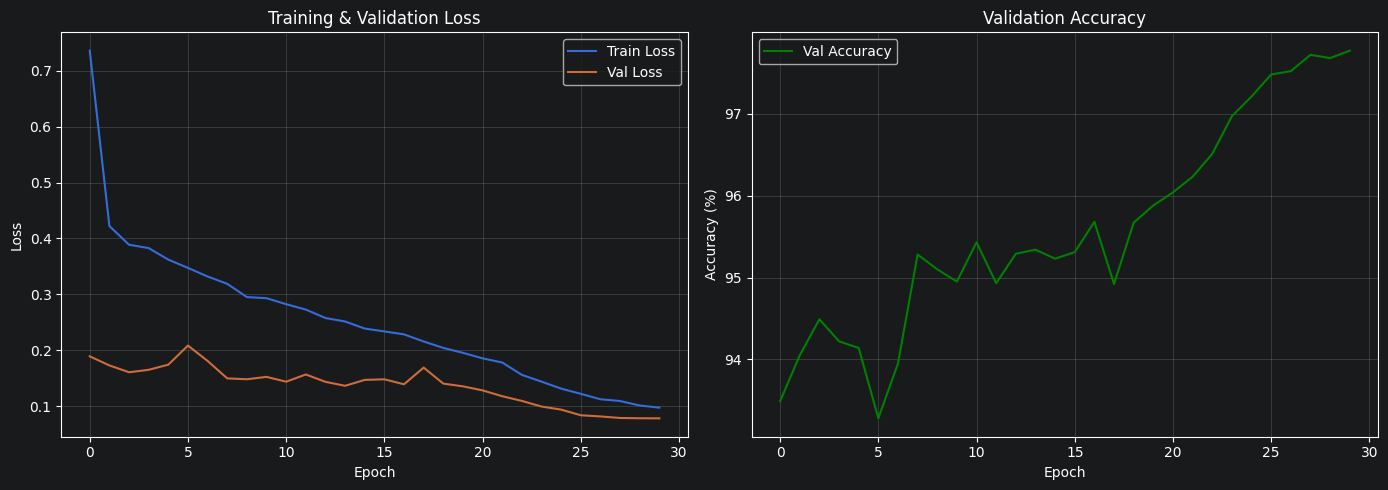

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(val_accuracies, label='Val Accuracy', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()